# AutoEIT — transcribed-v2 Summary & Distribution Analysis
Builds a per-recording `summary.json` for the Spanish-forced re-transcription output in
`data/transcribed/v2/` (produced by `src/transcription/transcribe_v2.py`), then plots:
1. Distribution of item count per recording — both versions combined, and each version separately.
2. Distribution of per-item mean word probability — both versions combined, and each version separately.

Note: `item_count` here is the size of the re-transcribed subset per recording (the items strictly
between the last English and last Spanish target-sentence items), not the full recording's item
count as in the original `data/transcribed/v1/` summaries.

In [1]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_V2_ROOT = Path("../../data/transcribed/v2")
VERSIONS = ["version_a", "version_b"]

## Build per-recording summaries
Same per-item metrics as `analyze_transcriptions.ipynb`: duration, language, word count, mean word
confidence, joined text, empty flag. Skips recordings that already have a `summary.json`.

In [3]:
def summarize_item(item_path: Path) -> dict:
    with open(item_path, encoding="utf-8") as f:
        data = json.load(f)

    index = int(re.search(r"item_(\d+)", item_path.stem).group(1))
    text = " ".join(seg["text"].strip() for seg in data["segments"]).strip()

    all_words = [w for seg in data["segments"] for w in seg.get("words", [])]
    word_count = len(all_words)
    mean_word_prob = round(sum(w["prob"] for w in all_words) / word_count, 4) if all_words else None

    return {
        "index": index,
        "duration": data["duration"],
        "language": data["language"],
        "language_probability": data["language_probability"],
        "word_count": word_count,
        "mean_word_prob": mean_word_prob,
        "text": text,
        "empty": word_count == 0,
    }


def build_recording_summary(recording_dir: Path, version: str) -> dict:
    item_files = sorted(recording_dir.glob("item_*.json"),
                        key=lambda p: int(re.search(r"item_(\d+)", p.stem).group(1)))
    items = [summarize_item(p) for p in item_files]
    return {
        "recording": recording_dir.name,
        "version": version,
        "item_count": len(items),
        "items": items,
    }

In [4]:
built = 0
skipped = 0

for version in VERSIONS:
    version_dir = TRANSCRIBED_V2_ROOT / version
    if not version_dir.exists():
        print(f"Not found: {version_dir}")
        continue
    for recording_dir in sorted(version_dir.iterdir()):
        if not recording_dir.is_dir():
            continue
        summary_path = recording_dir / "summary.json"
        if summary_path.exists():
            skipped += 1
            continue
        summary = build_recording_summary(recording_dir, version)
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(summary, f, ensure_ascii=False, indent=2)
        built += 1

print(f"Built {built} summaries, skipped {skipped} (already exist)")

Built 0 summaries, skipped 187 (already exist)


## Load summaries into DataFrames

In [5]:
recording_rows = []
item_rows = []

for version in VERSIONS:
    version_dir = TRANSCRIBED_V2_ROOT / version
    if not version_dir.exists():
        continue
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path, encoding="utf-8") as f:
            s = json.load(f)
        recording_rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
        })
        for it in s["items"]:
            item_rows.append({
                "recording": s["recording"],
                "version": s["version"],
                **it,
            })

df_rec = pd.DataFrame(recording_rows)
df_items = pd.DataFrame(item_rows)
print(f"{len(df_rec)} recordings, {len(df_items)} items total")

187 recordings, 6335 items total


## 1. Distribution of item count per recording
Combined (both versions), then version_a and version_b separately.

Item count per recording — describe:


,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
version_a,95.0,32.95,6.07,25.0,30.0,30.0,32.0,51.0
version_b,92.0,34.84,9.41,28.0,30.0,30.0,32.0,58.0


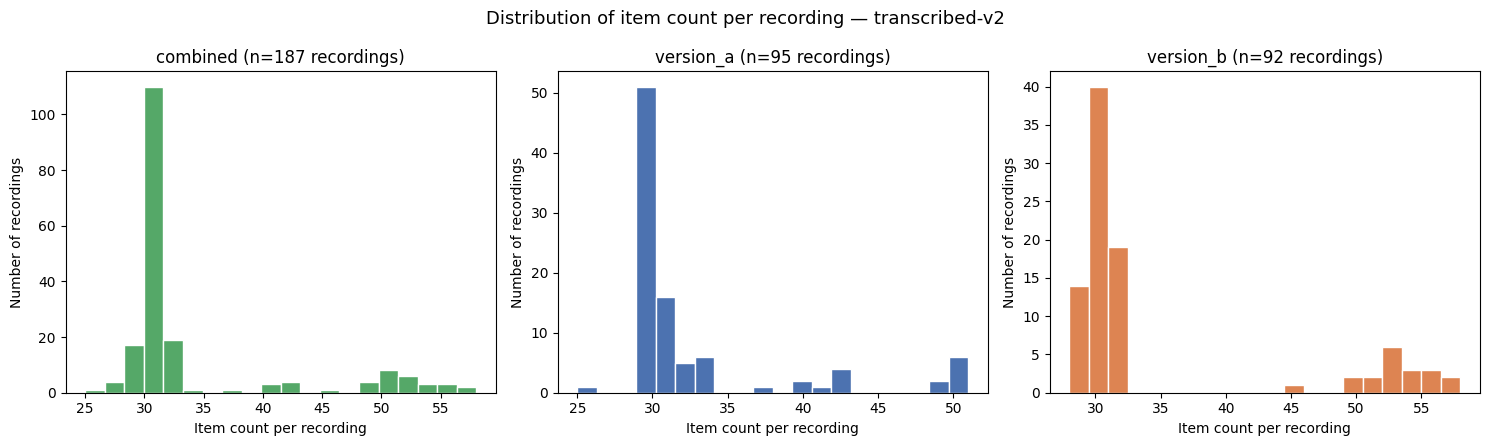

In [6]:
print("Item count per recording — describe:")
display(df_rec.groupby("version")["item_count"].describe().round(2))

colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}
panels = [("combined", df_rec, "#55A868"), ("version_a", df_rec[df_rec["version"] == "version_a"], colors["version_a"]),
          ("version_b", df_rec[df_rec["version"] == "version_b"], colors["version_b"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, (label, sub, color) in zip(axes, panels):
    ax.hist(sub["item_count"], bins=20, color=color, edgecolor="white")
    ax.set_title(f"{label} (n={len(sub)} recordings)", fontsize=12)
    ax.set_xlabel("Item count per recording")
    ax.set_ylabel("Number of recordings")

fig.suptitle("Distribution of item count per recording — transcribed-v2", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/transcribed_v2_item_count_distribution.png", dpi=150)
plt.show()

## 2. Distribution of mean word probability per item
Combined (both versions), then version_a and version_b separately.

Mean word probability per item — describe:


,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
version_a,3127.0,0.869,0.145,0.127,0.813,0.923,0.975,0.999
version_b,3204.0,0.856,0.154,0.137,0.795,0.913,0.970,0.999


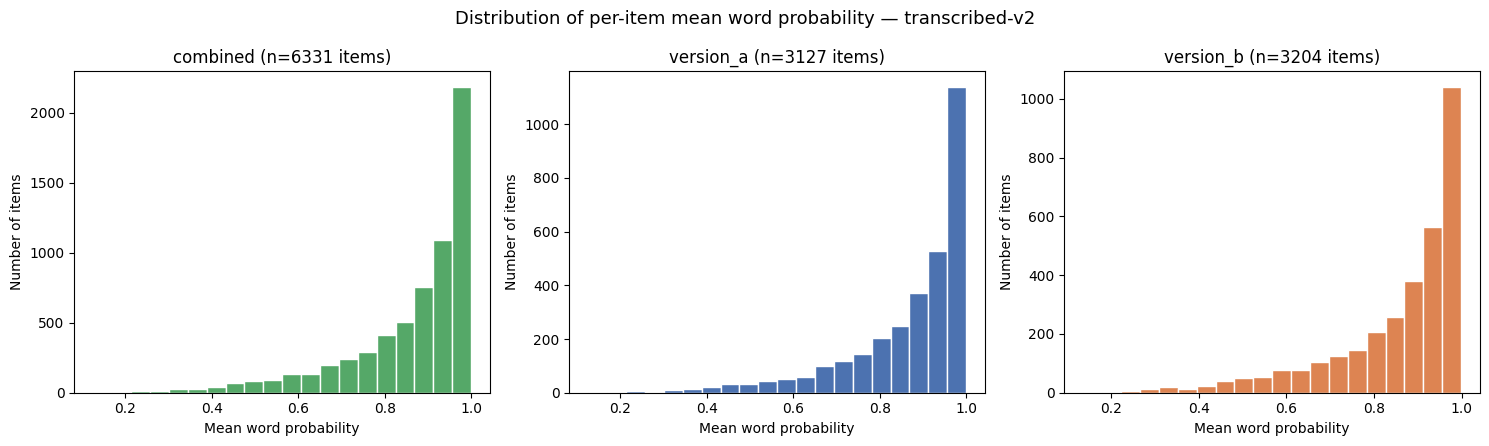

In [7]:
mwp = df_items.dropna(subset=["mean_word_prob"])
print("Mean word probability per item — describe:")
display(mwp.groupby("version")["mean_word_prob"].describe().round(3))

panels = [("combined", mwp, "#55A868"), ("version_a", mwp[mwp["version"] == "version_a"], colors["version_a"]),
          ("version_b", mwp[mwp["version"] == "version_b"], colors["version_b"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, (label, sub, color) in zip(axes, panels):
    ax.hist(sub["mean_word_prob"], bins=20, color=color, edgecolor="white")
    ax.set_title(f"{label} (n={len(sub)} items)", fontsize=12)
    ax.set_xlabel("Mean word probability")
    ax.set_ylabel("Number of items")

fig.suptitle("Distribution of per-item mean word probability — transcribed-v2", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/transcribed_v2_mean_word_prob_distribution.png", dpi=150)
plt.show()